In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [24]:
DRUG = "FLU"   # change to "FLU" when needed

# File selection
erg11_file = f"data/{DRUG}_ERG11.tsv"
wt_file = f"data/{DRUG}_WT.tsv"

erg11_df = pd.read_csv(erg11_file, sep="\t")
wt_df = pd.read_csv(wt_file, sep="\t")

erg11_df["Strain"] = "ERG11"
wt_df["Strain"] = "WT"

df = pd.concat([erg11_df, wt_df], ignore_index=True)

df.head()

,[FLU],Control,Ergosterol,Cholesterol,DMSO,Strain
0,10.000,0.139,0.149,0.144,0.143,ERG11
1,5.000,0.164,0.170,0.177,0.164,ERG11
2,2.500,0.162,0.470,0.194,0.233,ERG11
3,2.250,0.295,0.668,0.244,0.365,ERG11
4,1.125,0.691,0.702,0.695,0.670,ERG11


In [25]:
print(df.columns.tolist())

['[FLU]', 'Control', 'Ergosterol', 'Cholesterol', 'DMSO', 'Strain']


In [26]:
# Dynamic concentration column
conc_col = f"[{DRUG}]"

treatment_cols = ["Control", "Ergosterol", "Cholesterol", "DMSO"]

df_long = df.melt(
    id_vars=[conc_col, "Strain"],
    value_vars=treatment_cols,
    var_name="Treatment",
    value_name="OD"
)

df_long.head()

,[FLU],Strain,Treatment,OD
0,10.000,ERG11,Control,0.139
1,5.000,ERG11,Control,0.164
2,2.500,ERG11,Control,0.162
3,2.250,ERG11,Control,0.295
4,1.125,ERG11,Control,0.691


In [27]:
treatments_to_plot = ["Ergosterol", "Cholesterol", "DMSO"]
control_name = "Control"

# IMPORTANT: update if your labels differ
strain_order = ["WT", "ERG11"]

In [28]:
def four_param_logistic(x, bottom, top, ec50, hill):
    x = np.asarray(x, dtype=float)
    return bottom + (top - bottom) / (1.0 + (x / ec50) ** hill)

In [29]:
def fit_ec50(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]

    if len(x) < 4 or len(np.unique(x)) < 4:
        return np.nan, None

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    bottom0 = np.min(y)
    top0 = np.max(y)
    ec500 = np.median(x)
    hill0 = 1.0

    lower_bounds = [0, 0, np.min(x), 0.01]
    upper_bounds = [np.max(y) * 1.5, np.max(y) * 1.5 + 1e-9, np.max(x), 10]

    try:
        popt, _ = curve_fit(
            four_param_logistic,
            x,
            y,
            p0=[bottom0, top0, ec500, hill0],
            bounds=(lower_bounds, upper_bounds),
            maxfev=20000
        )
        ec50 = popt[2]
        return ec50, popt
    except Exception:
        return np.nan, None

In [30]:
plot_df = (
    df_long
    .groupby([conc_col, "Treatment", "Strain"], as_index=False)["OD"]
    .mean()
)

plot_df = plot_df[
    plot_df["Treatment"].isin([control_name] + treatments_to_plot)
].copy()

plot_df.head()

,[FLU],Treatment,Strain,OD
0,0.008789,Cholesterol,ERG11,0.742
1,0.008789,Cholesterol,WT,1.251
2,0.008789,Control,ERG11,0.749
3,0.008789,Control,WT,1.262
4,0.008789,DMSO,ERG11,0.823


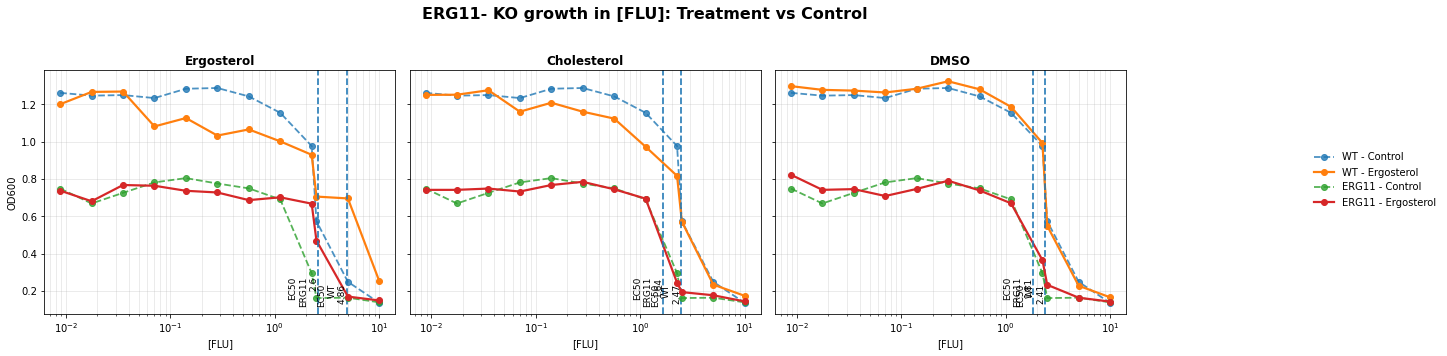

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, treatment in zip(axes, treatments_to_plot):

    for strain in strain_order:
        
        tr = plot_df[
            (plot_df["Treatment"] == treatment) &
            (plot_df["Strain"] == strain)
        ].sort_values(conc_col)

        ctrl = plot_df[
            (plot_df["Treatment"] == control_name) &
            (plot_df["Strain"] == strain)
        ].sort_values(conc_col)

        if not ctrl.empty:
            ax.plot(
                ctrl[conc_col],
                ctrl["OD"],
                marker="o",
                linestyle="--",
                linewidth=1.8,
                alpha=0.8,
                label=f"{strain} - {control_name}"
            )

        if not tr.empty:
            ax.plot(
                tr[conc_col],
                tr["OD"],
                marker="o",
                linestyle="-",
                linewidth=2.2,
                label=f"{strain} - {treatment}"
            )

            ec50, popt = fit_ec50(tr[conc_col].values, tr["OD"].values)

            if np.isfinite(ec50):
                ax.axvline(ec50, linestyle="--", linewidth=1.8, alpha=0.9)

                ymin, ymax = ax.get_ylim()
                ax.text(
                    ec50,
                    ymin + 0.03 * (ymax - ymin),
                    f"EC50\n{strain}\n{ec50:.3g}",
                    rotation=90,
                    va="bottom",
                    ha="right",
                    fontsize=9
                )

    ax.set_xscale("log")
    ax.set_title(treatment, fontweight="bold")
    ax.set_xlabel(f"[{DRUG}]")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("OD600")

fig.suptitle(
    f"ERG11- KO growth in [{DRUG}]: Treatment vs Control",
    fontsize=16,
    fontweight="bold"
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()

In [ ]:
fig.savefig(
    "OD_vs_PUL_1x3_with_control_overlay_EC50.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved: OD_vs_PUL_1x3_with_control_overlay_EC50.png")

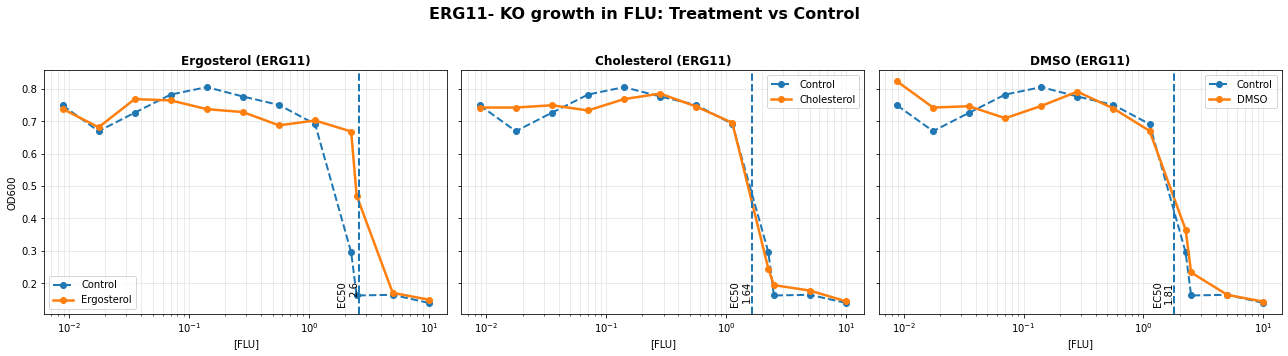

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

strain = "ERG11"   # update if your label differs

for ax, treatment in zip(axes, treatments_to_plot):

    # Treatment data
    tr = plot_df[
        (plot_df["Treatment"] == treatment) &
        (plot_df["Strain"] == strain)
    ].sort_values(conc_col)

    # Control data
    ctrl = plot_df[
        (plot_df["Treatment"] == control_name) &
        (plot_df["Strain"] == strain)
    ].sort_values(conc_col)

    # Plot control
    if not ctrl.empty:
        ax.plot(
            ctrl[conc_col],
            ctrl["OD"],
            marker="o",
            linestyle="--",
            linewidth=2,
            label="Control"
        )

    # Plot treatment
    if not tr.empty:
        ax.plot(
            tr[conc_col],
            tr["OD"],
            marker="o",
            linestyle="-",
            linewidth=2.5,
            label=treatment
        )

        # EC50 calculation
        ec50, popt = fit_ec50(tr[conc_col].values, tr["OD"].values)

        if np.isfinite(ec50):
            ax.axvline(ec50, linestyle="--", linewidth=2)

            ymin, ymax = ax.get_ylim()
            ax.text(
                ec50,
                ymin + 0.03 * (ymax - ymin),
                f"EC50\n{ec50:.3g}",
                rotation=90,
                va="bottom",
                ha="right",
                fontsize=10
            )

    ax.set_xscale("log")
    ax.set_title(f"{treatment} ({strain})", fontweight="bold")
    ax.set_xlabel(f"[{DRUG}]")
    ax.grid(True, which="both", alpha=0.3)

    # Legend inside
    ax.legend(loc="best", frameon=True)

axes[0].set_ylabel("OD600")

fig.suptitle(
    f"ERG11- KO growth in {DRUG}: Treatment vs Control",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()